In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("C://Users//lokes//OneDrive//Desktop//Neural_Network//spiral.csv")

In [3]:
df.head()

,x1,x2,y
0,0.000000,0.000000,0
1,-0.000650,0.010080,0
2,0.009809,0.017661,0
3,0.007487,0.029364,0
4,-0.000027,0.040404,0


In [4]:
df.shape

(300, 3)

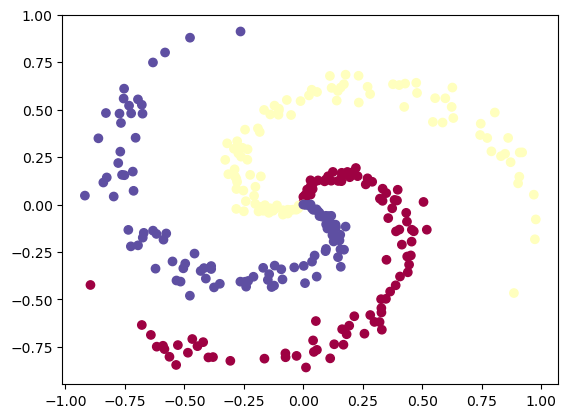

In [5]:
plt.scatter(df['x1'], df['x2'], c=df['y'], cmap=plt.cm.Spectral)
plt.show()

In [6]:
X = df.iloc[:,:-1].to_numpy()
y = df.iloc[:,-1].to_numpy()

In [7]:
y.shape

(300,)

In [8]:
# d = number of features/columns
# m = number of rows
# n = number of neurons/outputs

In [9]:
d = X.shape[1]
n = len(np.unique(y))
m = X.shape[0]

In [10]:
print(d,n,m)

2 3 300


In [11]:
# randomly generate weights (d,n)
w = 0.01*np.random.randn(d,n)

In [12]:
w.shape

(2, 3)

In [13]:
b = np.zeros((1,n))

In [14]:
X.shape

(300, 2)

In [15]:
b.shape

(1, 3)

In [16]:
z = np.dot(X,w)+b

In [17]:
ex = np.exp(z)

In [18]:
soft_max = ex/np.sum(ex, axis=1, keepdims=True)

In [19]:
X[1:3,:]

array([[-0.00065012,  0.01008007],
       [ 0.00980911,  0.01766078]])

In [20]:
y[1:3]

array([0, 0])

In [21]:
soft_max[1:3, :]

array([[0.33335946, 0.33333795, 0.33330258],
       [0.33337735, 0.33334699, 0.33327566]])

In [22]:
ex[1:3, :]

array([[1.00011256, 1.00004803, 0.99994192],
       [1.00026334, 1.00017221, 0.99995821]])

In [23]:
probabilities = soft_max.copy()

In [24]:
def backpro(proba, y):
    dz = proba
    dz[range(m), y] -= 1
    dw = np.dot(X.T, dz)
    db = np.sum(dz, axis=0, keepdims=True)
    return dw, db

In [25]:
w

array([[ 0.00603703,  0.00804334,  0.00547793],
       [ 0.0115557 ,  0.00528301, -0.00540887]])

In [26]:
backpro(probabilities, y)

(array([[-11.96291488, -16.33518287,  28.29809775],
        [ 26.55091426, -30.68032934,   4.12941508]]),
 array([[-0.01968314, -0.00788538,  0.02756852]]))

In [27]:
X.T.shape

(2, 300)

In [28]:
probabilities.shape

(300, 3)

In [29]:
max_iter = 500

In [30]:
d = 2
n = 3
h = 4 # number of neurons in the hidden layer

In [31]:
w1 = 0.01*np.random.randn(d,h)
b1 = np.zeros((1,h))
w2 = 0.01*np.random.randn(h,n)
b2 = np.zeros((1,n))

In [32]:
w1.shape

(2, 4)

In [33]:
X.shape

(300, 2)

In [34]:
z1 = np.dot(X,w1)+b1

In [35]:
m = len(X)
print(m)

300


# farword Propagation

In [36]:
Z1 = np.dot(X,w1)+b1

In [37]:
A1 = np.maximum(0,Z1)

In [38]:
Z2 = np.dot(A1,w2)+b2

In [39]:
A2 = np.exp(Z2)/np.sum(np.exp(Z2),axis=1,keepdims=True)

In [40]:
probs = A2

# Backword Propagation

In [41]:
dz2 = probs
dz2[range(m),y] -= 1 # predicted - actual (A2 - y)

In [42]:
dz2 = dz2/m

In [43]:
dw2 = np.dot(A1.T, dz2)

In [44]:
dw2

array([[ 0.00034513,  0.0002226 , -0.00056773],
       [-0.0004075 , -0.0001501 ,  0.0005576 ],
       [-0.00013424, -0.00021195,  0.00034619],
       [ 0.00019353, -0.00085294,  0.00065942]])

In [45]:
db2 = np.sum(dz2, axis=0, keepdims=True)

In [46]:
db2

array([[-2.86566635e-06,  1.30073485e-05, -1.01416822e-05]])

In [47]:
dA1 = np.dot(dz2, w2.T)

In [48]:
dA1.shape

(300, 4)

In [49]:
z.shape

(300, 3)

In [50]:
dA1[z1<0] = 0

In [51]:
dz1 = dA1

In [52]:
dw1 = np.dot(dz1.T,X)
db1 = np.sum(dz1,axis=1,keepdims=True)

In [53]:
w1

array([[-0.01035404,  0.01555603,  0.00899285,  0.01105731],
       [ 0.00124018, -0.00475597, -0.00067506,  0.00914768]])

In [54]:
w2

array([[-0.00616104,  0.00245016, -0.00139887],
       [ 0.00374403,  0.00633918, -0.01286765],
       [ 0.0113472 ,  0.0168962 ,  0.01415922],
       [-0.00668407,  0.00191856, -0.00372694]])

In [55]:
dw2

array([[ 0.00034513,  0.0002226 , -0.00056773],
       [-0.0004075 , -0.0001501 ,  0.0005576 ],
       [-0.00013424, -0.00021195,  0.00034619],
       [ 0.00019353, -0.00085294,  0.00065942]])

In [56]:
dw2

array([[ 0.00034513,  0.0002226 , -0.00056773],
       [-0.0004075 , -0.0001501 ,  0.0005576 ],
       [-0.00013424, -0.00021195,  0.00034619],
       [ 0.00019353, -0.00085294,  0.00065942]])

# specifiying Learning rate

In [57]:
lr = 1e-0

In [58]:
w1

array([[-0.01035404,  0.01555603,  0.00899285,  0.01105731],
       [ 0.00124018, -0.00475597, -0.00067506,  0.00914768]])

In [59]:
dw1

array([[ 3.58298421e-05, -3.35267631e-04],
       [-7.12684207e-04, -3.01588628e-04],
       [-4.52143014e-05, -3.02203266e-04],
       [-1.65669319e-04, -3.88702075e-04]])

In [60]:
w1 += -lr * dw1.T

In [61]:
w2 += -lr * dw2

In [62]:
w1

array([[-0.01038987,  0.01626872,  0.00903806,  0.01122298],
       [ 0.00157545, -0.00445438, -0.00037285,  0.00953638]])

In [63]:
w2

array([[-0.00650617,  0.00222756, -0.00083114],
       [ 0.00415154,  0.00648927, -0.01342525],
       [ 0.01148145,  0.01710815,  0.01381303],
       [-0.0068776 ,  0.00277151, -0.00438636]])

In [69]:
b2 += -lr * db2

In [70]:
b2

array([[ 2.86566635e-06, -1.30073485e-05,  1.01416822e-05]])

In [71]:
db2

array([[-2.86566635e-06,  1.30073485e-05, -1.01416822e-05]])

In [73]:
from sklearn.neural_network import MLPClassifier

In [82]:
mlp = MLPClassifier(max_iter=5000,hidden_layer_sizes=(50), learning_rate_init=1, activation='relu').fit(X,y)

In [83]:
mlp.score(X,y)

0.8833333333333333